In [61]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()

# Gör så att Python hittar src/
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_config

# Läs config
CONFIG_PATH = PROJECT_ROOT / "config.toml"
config = load_config(CONFIG_PATH, PROJECT_ROOT)


# Luftdata / PM2.5
air_df = pd.read_csv(
    config.raw_dir / "train_Malmö Dalaplan.csv"
)

# Väderdata
weather_df = pd.read_csv(
    config.raw_dir / "train_Malmö A.csv"
)

# Sammanfogad data
merged_df = pd.read_csv(
    config.merged_dir / "train_merged.csv"
)

## 1. Kontroll av struktur och datatyper

**Observation:**  
Samtliga mätvariabler är numeriska (`float64`). Tidsvariabeln `tid` är däremot inläst som `str` och behöver konverteras till `datetime` innan vidare analys av tidsserien.

Eftersom tidsstämplarna innehåller både svensk sommartid (CEST) och vintertid (CET) konverteras `tid` i denna notebook till timezone-aware `datetime` (`Europe/Stockholm`). Detta görs här för att möjliggöra korrekt analys av tidsserien. I den slutliga pipelinen bör konverteringen i stället hanteras vid inläsning av data.

In [62]:
print("LUFTDATA")
air_df.info()

print("\nVÄDERDATA")
weather_df.info()

print("\nMERGED DATA")
merged_df.info()

LUFTDATA
<class 'pandas.DataFrame'>
RangeIndex: 22855 entries, 0 to 22854
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tid     22855 non-null  str    
 1   pm25    22702 non-null  float64
dtypes: float64(1), str(1)
memory usage: 357.2 KB

VÄDERDATA
<class 'pandas.DataFrame'>
RangeIndex: 22290 entries, 0 to 22289
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tid                    22290 non-null  str    
 1   Lufttemperatur         22289 non-null  float64
 2   Vindriktning           22253 non-null  float64
 3   Vindhastighet          22253 non-null  float64
 4   Relativ luftfuktighet  22255 non-null  float64
 5   Nederbördsmängd        21756 non-null  float64
dtypes: float64(5), str(1)
memory usage: 1.0 MB

MERGED DATA
<class 'pandas.DataFrame'>
RangeIndex: 22857 entries, 0 to 22856
Data columns (total 7 columns):
 #   Column   

In [63]:
for df in [air_df, weather_df, merged_df]:
    df["tid"] = (pd.to_datetime(df["tid"], utc=True)
    .dt.tz_convert("Europe/Stockholm")
    )

print(air_df["tid"].dtype)
print(weather_df["tid"].dtype)
print(merged_df["tid"].dtype)

datetime64[us, Europe/Stockholm]
datetime64[us, Europe/Stockholm]
datetime64[us, Europe/Stockholm]


## 2. Kontroll av antal observationer och tidsintervall

**Förväntat antal observationer:** 22 825 timmar

**Observation:**
- PM2.5-data innehåller 22 855 observationer, alltså fler rader än det
  förväntade antalet timmar. Dessutom sträcker sig tidsintervallet till
  2026-01-01 00:00, trots att träningsperioden slutar 2025-12-31.
- Väderdata innehåller 22 290 observationer och följer det förväntade
  tidsintervallet 2023-05-26–2025-12-31.
- Merged data innehåller 22 857 observationer och sträcker sig också till
  2026-01-01 00:00.

Data har hämtats om med nuvarande konfiguration och avvikelsen
kvarstår. Filtreringen av PM2.5-data behöver därför kontrolleras,
framför allt hanteringen av start-/sluttid och tidszon.


In [64]:
config.train_start
config.train_slut

expected_timestamps = pd.date_range(
    start=config.train_start,
    end=f"{config.train_slut} 23:00:00",
    freq="h",
    tz="Europe/Stockholm"
)

expected_count = len(expected_timestamps)

print("Förväntat antal timmar:", expected_count)

print("Luftdata:", air_df.shape)
print("Väderdata:", weather_df.shape)
print("Merged:", merged_df.shape)

print("\nLUFTDATA")
print("Första:", air_df["tid"].min())
print("Sista:", air_df["tid"].max())

print("\nVÄDERDATA")
print("Första:", weather_df["tid"].min())
print("Sista:", weather_df["tid"].max())

print("\nMERGED")
print("Första:", merged_df["tid"].min())
print("Sista:", merged_df["tid"].max())

Förväntat antal timmar: 22825
Luftdata: (22855, 2)
Väderdata: (22290, 6)
Merged: (22857, 7)

LUFTDATA
Första: 2023-05-26 02:00:00+02:00
Sista: 2026-01-01 00:00:00+01:00

VÄDERDATA
Första: 2023-05-26 00:00:00+02:00
Sista: 2025-12-31 23:00:00+01:00

MERGED
Första: 2023-05-26 00:00:00+02:00
Sista: 2026-01-01 00:00:00+01:00


## 3. Kontroll av saknade värden

**Observation:**  
Merged data har en högre andel saknade värden än respektive ursprungsdata. 
Detta tyder på att dataseten delvis saknar observationer för olika tidsstämplar, 
vilket skapar ytterligare NaN-värden vid merge.

In [65]:
def missing_values(df):
    return pd.DataFrame({
        "Antal saknade": df.isna().sum(),
        "Andel saknade (%)": (df.isna().mean() * 100).round(2)
    })

print("\nLUFTDATA")
print(missing_values(air_df))

print("\nVÄDERDATA")
print(missing_values(weather_df))

print("\nMERGED DATA")
print(missing_values(merged_df))


LUFTDATA
      Antal saknade  Andel saknade (%)
tid               0               0.00
pm25            153               0.67

VÄDERDATA
                       Antal saknade  Andel saknade (%)
tid                                0               0.00
Lufttemperatur                     1               0.00
Vindriktning                      37               0.17
Vindhastighet                     37               0.17
Relativ luftfuktighet             35               0.16
Nederbördsmängd                  534               2.40

MERGED DATA
                       Antal saknade  Andel saknade (%)
tid                                0               0.00
pm25                             155               0.68
Lufttemperatur                   538               2.35
Vindriktning                     574               2.51
Vindhastighet                    574               2.51
Relativ luftfuktighet            572               2.50
Nederbördsmängd                 1074               4.70


## 4. Kontroll av dubbletter

**Observation:**   
PM2.5-data innehåller totalt 22 855 rader jämfört med 22 825 förväntade
timmar. Det finns 31 dubbla rader, samtliga med dubbla tidsstämplar, och
samma dubbletter återfinns i merged data.

Dubbletterna inträffar vid månadsskiften, klockan 00:00 den första dagen
i varje månad. Detta tyder på att de uppstår i samband med den månadsvisa
hämtningen av PM2.5-data från API:et.

Efter att dubbletterna räknats bort återstår 22 824 unika tidsstämplar,
vilket fortfarande inte överensstämmer med de 22 825 förväntade timmarna.
Eventuella tidsluckor behöver därför undersökas vidare.

In [66]:
duplicates = pd.DataFrame({
    "Dubbla rader": [
        air_df.duplicated().sum(),
        weather_df.duplicated().sum(),
        merged_df.duplicated().sum()
    ],
    "Dubbla tidsstämplar": [
        air_df["tid"].duplicated().sum(),
        weather_df["tid"].duplicated().sum(),
        merged_df["tid"].duplicated().sum()
    ]
}, index=["Luftdata", "Väderdata", "Merged data"])

print(duplicates)

weather_df[
    weather_df["tid"].duplicated(keep=False)
].sort_values("tid")

             Dubbla rader  Dubbla tidsstämplar
Luftdata               31                   31
Väderdata               0                    0
Merged data            31                   31


,tid,Lufttemperatur,Vindriktning,Vindhastighet,Relativ luftfuktighet,Nederbördsmängd


## 5. Kontroll av tidsluckor

**Observation:**  

**Luftdata (PM2.5)** 
Luftdata saknar de två första förväntade tidsstämplarna i träningsperioden,
2023-05-26 kl. 00:00 och 01:00. Tillsammans med de tidigare identifierade
dubbletterna vid månadsskiften och en observation utanför träningsperioden
tyder detta på att avvikelserna kan vara kopplade till hur data hämtas och
tidsintervallet avgränsas.

**Väderdata**  
Väderdata saknar 535 tidsstämplar under träningsperioden och luckorna är
inte jämnt fördelade. Den största sammanhängande luckan omfattar 296 timmar,
från 2024-08-06 kl. 06:00 till 2024-08-18 kl. 13:00.

Under vissa perioder finns dessutom skillnader i datatillgänglighet mellan
väderparametrarna. Exempelvis saknas den normala timvisa serien under delar
av april 2025, medan lufttemperatur fortfarande finns registrerad ungefär
var sjätte timme. Övriga vädervariabler saknas vid dessa tidpunkter.

Detta tyder på att luckorna åtminstone delvis beror på varierande
datatillgänglighet i de underliggande väderserierna.

**Merged data**  
Merged data innehåller samtliga förväntade tidsstämplar eftersom en
tidsstämpel behålls när den finns i minst en av datakällorna. Saknade
observationer i den andra datakällan representeras då som NaN.

In [67]:
expected_timestamps = pd.date_range(
    start=f"{config.train_start} 00:00",
    end=f"{config.train_slut} 23:00",
    freq="h",
    tz="Europe/Stockholm"
)

def missing_timestamps(df):
    actual = pd.DatetimeIndex(df["tid"].drop_duplicates())
    return expected_timestamps.difference(actual)

missing_air = missing_timestamps(air_df)
missing_weather = missing_timestamps(weather_df)
missing_merged = missing_timestamps(merged_df)

print("Luftdata (PM2.5):", len(missing_air))
print("Väderdata:", len(missing_weather))
print("Merged data:", len(missing_merged))

print("Saknade tidsstämplar i luftdata:")
print(missing_air)

print("\nSaknade tidsstämplar i väderdata:")
print(missing_weather)

missing_weather_df = pd.DataFrame({
    "tid": missing_weather
})

# Ny grupp varje gång avståndet till föregående saknade tid är > 1 timme
missing_weather_df["grupp"] = (
    missing_weather_df["tid"].diff() > pd.Timedelta(hours=1)
).cumsum()

weather_gaps = (
    missing_weather_df
    .groupby("grupp")
    .agg(
        start=("tid", "min"),
        slut=("tid", "max"),
        antal_timmar=("tid", "size")
    )
    .reset_index(drop=True)
)

print(weather_gaps)

weather_april = weather_df[
    (weather_df["tid"] >= "2025-04-01") &
    (weather_df["tid"] < "2025-04-05")
]

weather_april

Luftdata (PM2.5): 2
Väderdata: 535
Merged data: 0
Saknade tidsstämplar i luftdata:
DatetimeIndex(['2023-05-26 00:00:00+02:00', '2023-05-26 01:00:00+02:00'], dtype='datetime64[us, Europe/Stockholm]', freq='h')

Saknade tidsstämplar i väderdata:
DatetimeIndex(['2023-06-08 10:00:00+02:00', '2024-08-06 06:00:00+02:00',
               '2024-08-06 07:00:00+02:00', '2024-08-06 08:00:00+02:00',
               '2024-08-06 09:00:00+02:00', '2024-08-06 10:00:00+02:00',
               '2024-08-06 11:00:00+02:00', '2024-08-06 12:00:00+02:00',
               '2024-08-06 13:00:00+02:00', '2024-08-06 14:00:00+02:00',
               ...
               '2025-07-07 05:00:00+02:00', '2025-07-07 06:00:00+02:00',
               '2025-07-07 07:00:00+02:00', '2025-07-07 09:00:00+02:00',
               '2025-07-07 10:00:00+02:00', '2025-07-07 11:00:00+02:00',
               '2025-07-07 12:00:00+02:00', '2025-07-07 13:00:00+02:00',
               '2025-07-07 15:00:00+02:00', '2025-07-07 16:00:00+02:00'],
      

,tid,Lufttemperatur,Vindriktning,Vindhastighet,Relativ luftfuktighet,Nederbördsmängd
15927,2025-04-01 00:00:00+02:00,5.1,333.0,2.4,93.0,NaN
15928,2025-04-01 01:00:00+02:00,3.7,346.0,1.2,94.0,NaN
15929,2025-04-01 02:00:00+02:00,2.9,344.0,1.1,96.0,NaN
15930,2025-04-01 08:00:00+02:00,4.0,NaN,NaN,NaN,NaN
15931,2025-04-01 14:00:00+02:00,13.0,NaN,NaN,NaN,NaN
15932,2025-04-01 20:00:00+02:00,10.0,NaN,NaN,NaN,NaN
15933,2025-04-02 08:00:00+02:00,5.5,NaN,NaN,NaN,NaN
15934,2025-04-02 14:00:00+02:00,15.0,NaN,NaN,NaN,NaN
15935,2025-04-02 20:00:00+02:00,11.0,NaN,NaN,NaN,NaN
15936,2025-04-03 08:00:00+02:00,8.0,NaN,NaN,NaN,NaN


## 6. Kontroll av sammanhängande saknade värden

Även när en tidsstämpel finns kan ett eller flera mätvärden saknas (`NaN`).
Därför undersöks hur långa de sammanhängande perioderna med saknade värden
är för respektive variabel.

**Observation** 
De saknade värdena är inte jämnt fördelade över tidsserien. PM2.5 har främst kortare luckor men även en längre sammanhängande lucka på 93 timmar. Vädervariablerna har flera längre gemensamma bortfallsperioder, särskilt i augusti 2024 samt under delar av april och juni–juli 2025. Nederbördsmängd uppvisar dessutom fler och delvis längre luckor än övriga variabler.

,Variabel,1 h,2 h,3 h,4–6 h,7–24 h,25h–168 h (≤1 week),>168 h (>1 week),Längsta lucka (h)
0,pm25,7,3,0,1,3,1,0,93
1,Lufttemperatur,4,1,0,23,11,0,1,296
2,Vindriktning,3,1,0,0,0,1,2,296
3,Vindhastighet,3,1,0,0,0,1,2,296
4,Relativ luftfuktighet,3,0,0,0,0,1,2,296
5,Nederbördsmängd,25,9,1,0,13,4,2,317


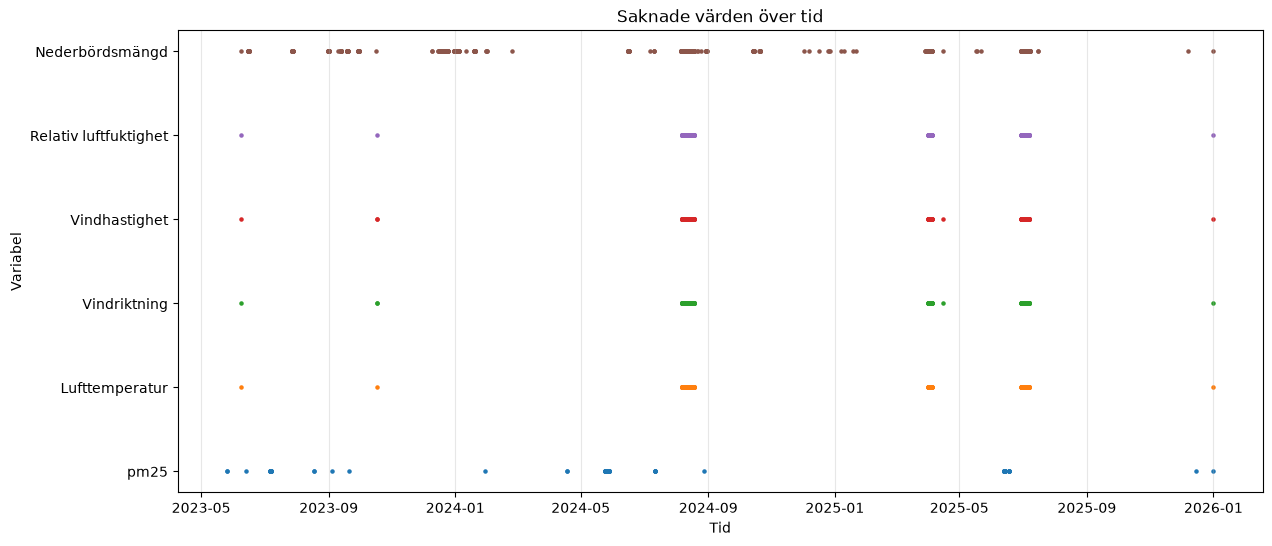

,Antal saknade variabler,Antal timmar
1,1,656
2,2,1
3,3,1
4,4,35
5,5,536
6,6,1


                            tid  pm25  Lufttemperatur  Vindriktning  \
22856 2026-01-01 00:00:00+01:00   NaN             NaN           NaN   

       Vindhastighet  Relativ luftfuktighet  Nederbördsmängd  
22856            NaN                    NaN              NaN  


,start,end,antal_timmar,Saknade variabler
0,2023-08-31 09:00:00+02:00,2023-09-01 08:00:00+02:00,25,Nederbördsmängd
1,2023-12-21 08:00:00+01:00,2023-12-22 19:00:00+01:00,36,Nederbördsmängd
2,2023-12-30 20:00:00+01:00,2024-01-01 07:00:00+01:00,37,Nederbördsmängd
3,2024-05-24 13:00:00+02:00,2024-05-28 09:00:00+02:00,93,pm25
4,2024-08-05 09:00:00+02:00,2024-08-18 13:00:00+02:00,317,Nederbördsmängd
5,2024-08-06 06:00:00+02:00,2024-08-18 13:00:00+02:00,296,"Lufttemperatur, Vindriktning, Vindhastighet, Relativ luftfuktighet"
6,2025-03-31 09:00:00+02:00,2025-04-04 12:00:00+02:00,101,Nederbördsmängd
7,2025-04-01 03:00:00+02:00,2025-04-04 12:00:00+02:00,82,"Vindriktning, Vindhastighet, Relativ luftfuktighet"
8,2025-06-29 09:00:00+02:00,2025-07-08 08:00:00+02:00,217,Nederbördsmängd
9,2025-06-29 19:00:00+02:00,2025-07-07 16:00:00+02:00,191,"Vindriktning, Vindhastighet, Relativ luftfuktighet"


,Variabel,Totalt saknade,Kan fyllas ≤3 h,Kvar efter 3 h,Kan fyllas ≤6 h,Kvar efter 6 h
0,pm25,155,13,142,18,137
1,Lufttemperatur,538,6,532,120,418
2,Vindriktning,574,5,569,5,569
3,Vindhastighet,574,5,569,5,569
4,Relativ luftfuktighet,572,3,569,3,569
5,Nederbördsmängd,1074,46,1028,46,1028


Antal timmar där nederbörd saknas: 1074

Hur ofta saknas även övriga vädervariabler?


Lufttemperatur           537
Vindriktning             572
Vindhastighet            572
Relativ luftfuktighet    571
dtype: int64

,start,end,antal_timmar,före,efter
0,2023-06-08 10:00:00+02:00,2023-06-08 10:00:00+02:00,1,0.0,0.0
4,2023-09-09 15:00:00+02:00,2023-09-09 15:00:00+02:00,1,0.0,0.0
8,2023-10-16 11:00:00+02:00,2023-10-16 11:00:00+02:00,1,0.0,0.0
9,2023-12-09 17:00:00+01:00,2023-12-09 18:00:00+01:00,2,0.2,0.0
10,2023-12-15 02:00:00+01:00,2023-12-15 03:00:00+01:00,2,0.0,0.0
12,2023-12-20 02:00:00+01:00,2023-12-20 03:00:00+01:00,2,0.0,0.0
14,2023-12-24 22:00:00+01:00,2023-12-24 23:00:00+01:00,2,1.9,0.0
15,2023-12-25 02:00:00+01:00,2023-12-25 04:00:00+01:00,3,0.0,0.0
18,2024-01-11 09:00:00+01:00,2024-01-11 09:00:00+01:00,1,0.0,0.0
20,2024-01-30 17:00:00+01:00,2024-01-30 18:00:00+01:00,2,0.0,0.0


,start,end,antal_timmar,före,efter
0,2023-06-08 10:00:00+02:00,2023-06-08 10:00:00+02:00,1,255.0,263.0
1,2023-10-17 09:00:00+02:00,2023-10-17 10:00:00+02:00,2,279.0,285.0
4,2025-04-15 15:00:00+02:00,2025-04-15 15:00:00+02:00,1,90.0,74.0
6,2026-01-01 00:00:00+01:00,2026-01-01 00:00:00+01:00,1,190.0,<NA>


In [107]:
def find_nan_gaps(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """Hittar sammanhängande perioder med saknade värden i en kolumn."""

    missing = df[column].isna()
    groups = missing.ne(missing.shift()).cumsum()

    gaps = (
        df[missing]
        .groupby(groups[missing])
        .agg(
            start=("tid", "first"),
            end=("tid", "last"),
            antal_timmar=("tid", "size")
        )
        .reset_index(drop=True)
    )

    return gaps


# Mätvariabler
value_columns = merged_df.columns.drop("tid")


# Sammanfatta längden på NaN-luckorna
summary = []

for column in value_columns:
    gaps = find_nan_gaps(merged_df, column)

    summary.append({
        "Variabel": column,
        "1 h": (gaps["antal_timmar"] == 1).sum(),
        "2 h": (gaps["antal_timmar"] == 2).sum(),
        "3 h": (gaps["antal_timmar"] == 3).sum(),
        "4–6 h": gaps["antal_timmar"].between(4, 6).sum(),
        "7–24 h": gaps["antal_timmar"].between(7, 24).sum(),
        "25h–168 h (≤1 week)": gaps["antal_timmar"].between(25, 168).sum(),
        ">168 h (>1 week)": (gaps["antal_timmar"] > 168).sum(),
        "Längsta lucka (h)": gaps["antal_timmar"].max()
    })

gap_summary = pd.DataFrame(summary)

display(gap_summary)


# Visualisera när de saknade värdena förekommer
plt.figure(figsize=(14, 6))

for i, column in enumerate(value_columns):
    missing = merged_df[column].isna()

    plt.scatter(
        merged_df.loc[missing, "tid"],
        [i] * missing.sum(),
        s=5
    )

plt.yticks(range(len(value_columns)), value_columns)
plt.xlabel("Tid")
plt.ylabel("Variabel")
plt.title("Saknade värden över tid")
plt.grid(axis="x", alpha=0.3)

plt.show()


# Antal saknade variabler per tidsstämpel,
# uppdelat efter vilken variabel som saknas
# missing_by_variable = (
#     merged_df[value_columns]
#     .isna()
#     .astype(int)
# )

# plt.figure(figsize=(14, 5))

# plt.stackplot(
#     merged_df["tid"],
#     *[missing_by_variable[column] for column in value_columns],
#     labels=value_columns
# )

# plt.xlabel("Tid")
# plt.ylabel("Antal saknade variabler")
# plt.title("Saknade värden per tidsstämpel och variabel")
# plt.yticks(range(len(value_columns) + 1))
# plt.legend(loc="upper left")
# plt.grid(alpha=0.3)

# plt.show()


# Antal saknade variabler vid varje timme
nan_per_timestamp = merged_df[value_columns].isna().sum(axis=1)

# Sammanställ antal timmar
missing_together = (
    nan_per_timestamp
    .value_counts()
    .sort_index()
    .rename_axis("Antal saknade variabler")
    .reset_index(name="Antal timmar")
)

# Visa bara timmar där minst ett värde saknas
missing_together = missing_together[
    missing_together["Antal saknade variabler"] > 0
]

display(missing_together)

# När inträffar den som saknar alla värden.
print(merged_df.loc[
    merged_df[value_columns].isna().sum(axis=1) == 6
])


long_gaps = []

for column in value_columns:
    gaps = find_nan_gaps(merged_df, column)

    gaps = gaps[gaps["antal_timmar"] > 24].copy()
    gaps["Variabel"] = column

    long_gaps.append(gaps)

long_gaps = pd.concat(long_gaps, ignore_index=True)

long_gaps = long_gaps[
    ["Variabel", "start", "end", "antal_timmar"]
]

long_gaps_grouped = (
    long_gaps
    .groupby(["start", "end", "antal_timmar"])["Variabel"]
    .agg(", ".join)
    .reset_index(name="Saknade variabler")
    .sort_values("start")
    .reset_index(drop=True)
)

pd.set_option("display.max_colwidth", None)

display(long_gaps_grouped)

#Kolla hur många värden som påverkas vid olika gränser: 
# Jämför hur många saknade värden som ligger i korta luckor
# vid olika möjliga gränser för interpolation

comparison = []

for column in value_columns:
    gaps = find_nan_gaps(merged_df, column)

    total_missing = gaps["antal_timmar"].sum()

    missing_max_3h = gaps.loc[
        gaps["antal_timmar"] <= 3, "antal_timmar"
    ].sum()

    missing_max_6h = gaps.loc[
        gaps["antal_timmar"] <= 6, "antal_timmar"
    ].sum()

    comparison.append({
        "Variabel": column,
        "Totalt saknade": total_missing,
        "Kan fyllas ≤3 h": missing_max_3h,
        "Kvar efter 3 h": total_missing - missing_max_3h,
        "Kan fyllas ≤6 h": missing_max_6h,
        "Kvar efter 6 h": total_missing - missing_max_6h
    })

interpolation_comparison = pd.DataFrame(comparison)

display(interpolation_comparison)


# Undersök vad som händer när nederbördsmängd saknas

rain_missing = merged_df[
    merged_df["Nederbördsmängd"].isna()
]

weather_columns = [
    "Lufttemperatur",
    "Vindriktning",
    "Vindhastighet",
    "Relativ luftfuktighet"
]

print("Antal timmar där nederbörd saknas:", len(rain_missing))

print("\nHur ofta saknas även övriga vädervariabler?")
display(
    rain_missing[weather_columns]
    .isna()
    .sum()
)

# Markera timmar där nederbörd saknas men temperatur finns
# Identifiera sammanhängande luckor i nederbördsdata
rain_gaps = find_nan_gaps(
    merged_df,
    "Nederbördsmängd"
)

# Lägg till nederbördsvärdet precis före och efter varje lucka
before_values = []
after_values = []

for _, gap in rain_gaps.iterrows():

    before = merged_df.loc[
        merged_df["tid"] < gap["start"],
        "Nederbördsmängd"
    ]

    after = merged_df.loc[
        merged_df["tid"] > gap["end"],
        "Nederbördsmängd"
    ]

    before_values.append(
        before.iloc[-1] if not before.empty else pd.NA
    )

    after_values.append(
        after.iloc[0] if not after.empty else pd.NA
    )

rain_gaps["före"] = before_values
rain_gaps["efter"] = after_values

# Visa bara korta luckor
short_rain_gaps = rain_gaps[
    rain_gaps["antal_timmar"] <= 3
]

display(short_rain_gaps)


wind_gaps = find_nan_gaps(
    merged_df,
    "Vindriktning"
)

short_wind_gaps = wind_gaps[
    wind_gaps["antal_timmar"] <= 3
].copy()

before_values = []
after_values = []

for _, gap in short_wind_gaps.iterrows():

    before = merged_df.loc[
        merged_df["tid"] < gap["start"],
        "Vindriktning"
    ]

    after = merged_df.loc[
        merged_df["tid"] > gap["end"],
        "Vindriktning"
    ]

    before_values.append(
        before.iloc[-1] if not before.empty else pd.NA
    )

    after_values.append(
        after.iloc[0] if not after.empty else pd.NA
    )

short_wind_gaps["före"] = before_values
short_wind_gaps["efter"] = after_values

display(short_wind_gaps)

## 7. Rimlighetskontroll av mätvärden

**Observation:**  
De numeriska variablernas min- och maxvärden ligger inom rimliga intervall.
Inga uppenbart orimliga värden identifieras i den deskriptiva statistiken.

PM2.5 varierar mellan 0,40 och 69,14 µg/m³. Maxvärdet ligger tydligt över
medianen och övre kvartilen, men kan representera en faktisk kortvarig
föroreningstopp och bör därför undersökas innan det eventuellt klassificeras
som ett avvikande värde.

Även vädervariablernas intervall framstår som rimliga. Ingen nederbörd är
negativ, relativ luftfuktighet ligger mellan 19 och 99 %, och vindriktningen
ligger inom intervallet 0–360°.

In [93]:
print("LUFTDATA (PM2.5)")
display(air_df.describe().round(2))

print("VÄDERDATA")
display(weather_df.describe().round(2))

print(air_df.nlargest(20, "pm25")[["tid", "pm25"]])

max_index = air_df["pm25"].idxmax()
max_tid = air_df.loc[max_index, "tid"]

around_max = air_df[
    air_df["tid"].between(
        max_tid - pd.Timedelta(hours=6),
        max_tid + pd.Timedelta(hours=6)
    )
]

print(around_max[["tid", "pm25"]])

LUFTDATA (PM2.5)


,pm25
count,22702.00
mean,7.52
std,6.26
min,0.40
25%,3.68
50%,5.72
75%,9.28
max,69.14


VÄDERDATA


,Lufttemperatur,Vindriktning,Vindhastighet,Relativ luftfuktighet,Nederbördsmängd
count,22289.00,22253.00,22253.00,22255.00,21756.00
mean,10.61,183.65,2.65,79.15,0.07
std,7.02,103.70,1.82,15.21,0.46
min,-12.10,0.00,0.00,19.00,0.00
25%,5.10,103.00,1.30,70.00,0.00
50%,10.60,199.00,2.40,84.00,0.00
75%,16.20,269.00,3.70,91.00,0.00
max,30.00,360.00,13.10,99.00,17.50


                            tid    pm25
6760  2024-03-02 07:00:00+01:00  69.138
5288  2024-01-01 01:00:00+01:00  59.741
6772  2024-03-02 19:00:00+01:00  59.724
4704  2023-12-07 18:00:00+01:00  59.130
6759  2024-03-02 06:00:00+01:00  58.491
4709  2023-12-07 23:00:00+01:00  58.391
6741  2024-03-01 12:00:00+01:00  57.934
4705  2023-12-07 19:00:00+01:00  57.174
6740  2024-03-01 11:00:00+01:00  56.826
6761  2024-03-02 08:00:00+01:00  56.643
6745  2024-03-01 16:00:00+01:00  55.128
15677 2025-03-08 08:00:00+01:00  54.852
6755  2024-03-02 02:00:00+01:00  54.795
6744  2024-03-01 15:00:00+01:00  54.565
15674 2025-03-08 05:00:00+01:00  54.516
4710  2023-12-08 00:00:00+01:00  54.338
15678 2025-03-08 09:00:00+01:00  54.102
6769  2024-03-02 16:00:00+01:00  53.989
6756  2024-03-02 03:00:00+01:00  53.918
7197  2024-03-20 12:00:00+01:00  53.907
                           tid    pm25
6754 2024-03-02 01:00:00+01:00  49.743
6755 2024-03-02 02:00:00+01:00  54.795
6756 2024-03-02 03:00:00+01:00  53.918
6757

**Fördelning och extremvärden för PM2.5**

Fördelningen av PM2.5 är tydligt högerskev. Majoriteten av observationerna
ligger på relativt låga nivåer, medan ett mindre antal observationer bildar
en lång svans med höga värden.

IQR-metoden identifierar 1 353 observationer över den övre gränsen på
17,68 µg/m³. Dessa betraktas inte automatiskt som felaktiga värden.
Det högsta värdet, 69,14 µg/m³, omges av flera timmar med förhöjda nivåer,
vilket talar för att det ingår i en faktisk föroreningsepisod.

Fördelningens skevhet bör beaktas vid den senare modellutvärderingen,
eftersom modellens prestanda kan skilja sig mellan vanliga låga nivåer
och mer ovanliga perioder med höga PM2.5-halter.


Nedre gräns: -4.71
Övre gräns: 17.68
Antal statistiska outliers: 1353


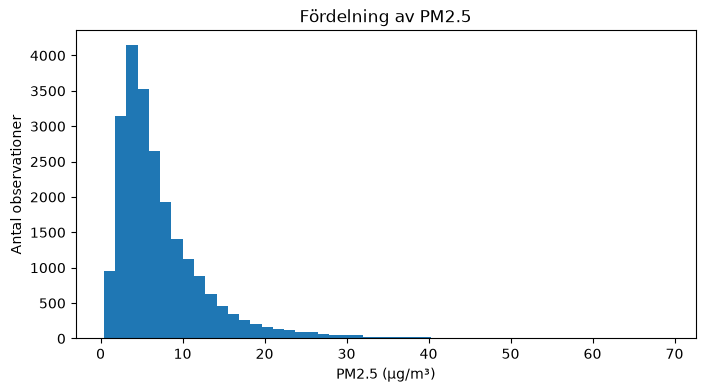

In [94]:
# Outliers
q1 = air_df["pm25"].quantile(0.25)
q3 = air_df["pm25"].quantile(0.75)

iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

print("\nNedre gräns:", round(lower_limit, 2))
print("Övre gräns:", round(upper_limit, 2))

outliers = air_df[
    (air_df["pm25"] < lower_limit) |
    (air_df["pm25"] > upper_limit)
]

print("Antal statistiska outliers:", len(outliers))

plt.figure(figsize=(8, 4))
plt.hist(air_df["pm25"].dropna(), bins=50)

plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Antal observationer")
plt.title("Fördelning av PM2.5")

plt.show()

## 8. Sammanfattning av datakvalitet och föreslagna åtgärder

Datakvalitetsanalysen visar att både PM2.5- och väderdatan innehåller
avvikelser som behöver hanteras innan data används för modellering.

**Datatyper**  
- Tidsvariabeln `tid` läses in från CSV som `str` och behöver konverteras
  till timezone-aware `datetime` (`Europe/Stockholm`) innan tidsserieanalys
  och modellering.
- Konverteringen görs i denna notebook för analysen, men bör i den slutliga
  datapipelinen hanteras vid inläsning av data.

**Luftdata (PM2.5)**  
- 31 dubbla tidsstämplar har identifierats vid månadsskiften. Dessa verkar
  uppstå i samband med den månadsvisa datahämtningen och bör i första hand
  hanteras i hämtningen av PM2.5-data.
- De två första timmarna i träningsperioden saknas.
- En tidsstämpel ligger utanför den definierade träningsperioden.
- 153 PM2.5-värden saknas vid befintliga tidsstämplar.
- Inga uppenbart orimliga mätvärden har identifierats. Fördelningen är
  tydligt högerskev, men höga PM2.5-värden bedöms kunna representera
  verkliga föroreningsepisoder och bör därför inte tas bort enbart för
  att de är statistiska extremvärden.

**Väderdata**  
- 535 förväntade tidsstämplar saknas.
- Luckorna är ojämnt fördelade och inkluderar både en längre sammanhängande
  period och perioder med varierande datatillgänglighet mellan
  väderparametrarna.
- Saknade värden förekommer även vid tidsstämplar som finns i datasetet,
  framför allt för nederbörd.
- Inga uppenbart orimliga numeriska värden har identifierats.
- Vindriktningen innehåller 21 observationer med värdet 360°. Värdet motsvarar samma riktning som 0° (nord).

**Merged data**  
- Den sammanslagna datan innehåller samtliga förväntade tidsstämplar eftersom
  en tidsstämpel behålls när den förekommer i minst en av datakällorna.
- Luckor i respektive datakälla representeras därför som saknade värden
  (`NaN`) i den sammanslagna datan.


### Konsekvenser för preprocessing

1. **Tidsvariabel, tidsintervall och dubbletter:** `tid` konverteras till timezone-aware `datetime` (`Europe/Stockholm`). Observationer utanför det definierade tidsintervallet och dubbletter hanteras, varefter en unik och komplett timaxel säkerställs.

2. **Korta NaN-luckor:** Korta luckor kan fyllas med en metod som är lämplig för respektive variabel. En maximal längd för vilka luckor som får fyllas behöver fastställas.

3. **Långa NaN-luckor:** Längre sammanhängande luckor ska inte interpoleras, eftersom detta skulle innebära att stora mängder syntetiska värden skapas.

4. **Variabelspecifik hantering:** Samma metod behöver inte vara lämplig för alla variabler. Vindriktning behöver hanteras som en cirkulär variabel och värdet 360° normaliseras till 0°. Nederbörd behöver hanteras separat eftersom linjär interpolation inte är lämplig.

5. **Omfattande gemensamt bortfall:** Perioder där flera vädervariabler saknas under längre tid ska inte fyllas genom omfattande interpolation. Observationer som fortfarande innehåller saknade värden efter preprocessing kan behöva exkluderas från datasetet som används för modellering.

## 9. Beslut om hantering av saknade värden

Analysen visar att saknade värden inte bör hanteras med en gemensam metod för
samtliga variabler. Hanteringen behöver ta hänsyn till variabelns egenskaper,
luckans längd och om bortfallet är en del av en längre period med reducerad
datatillgänglighet.

I preprocessing definieras en **kort lucka som högst 3 sammanhängande timmar**.
Gränsen väljs för att möjliggöra hantering av korta, isolerade bortfall utan att
interpolera längre perioder med reducerad datatillgänglighet. Analysen visar
exempelvis att en gräns på 6 timmar skulle medföra att ett stort antal saknade
temperaturvärden interpoleras under perioder där temperatur endast rapporterats
ungefär var sjätte timme.

| Variabel | Beslut för preprocessing |
|---|---|
| PM2.5 | Korta luckor på högst 3 timmar interpoleras linjärt. Längre luckor lämnas som `NaN`. |
| Lufttemperatur | Korta luckor på högst 3 timmar interpoleras linjärt. Längre luckor lämnas som `NaN`. Detta innebär att 4–6-timmarsluckorna under perioder med reducerad rapporteringsfrekvens inte fylls. |
| Vindhastighet | Korta luckor på högst 3 timmar interpoleras linjärt. Längre luckor lämnas som `NaN`. |
| Vindriktning | Korta luckor på högst 3 timmar interpoleras cirkulärt för att ta hänsyn till att vindriktning anges på en cirkulär skala där 0° och 360° representerar samma riktning. Längre luckor lämnas som `NaN`. |
| Relativ luftfuktighet | Korta luckor på högst 3 timmar interpoleras linjärt. Längre luckor lämnas som `NaN`. |
| Nederbördsmängd | Korta luckor på högst 3 timmar fylls med 0 endast om nederbördsmängden är 0 både omedelbart före och efter luckan. Övriga saknade nederbördsvärden lämnas som `NaN`. Längre luckor interpoleras inte. |

### Kvarvarande saknade värden

Längre luckor lämnas kvar som `NaN` efter den variabelspecifika hanteringen.
Perioder där flera vädervariabler saknas samtidigt ska inte rekonstrueras genom
omfattande interpolation.

Kvarvarande `NaN` behålls i den preprocessade datan. Rader med saknade värden
tas endast bort om de inte kan användas av den modell som senare väljs.
Rådata och den sammanslagna datan behålls oförändrade.